In [ ]:
import gymnasium as gym
import numpy as np

from sb3_contrib import TRPO

env = gym.make("Hopper-v4")

model = TRPO("MlpPolicy", env, verbose=1, device='cpu', gae_lambda=0.0, seed=0, cg_damping=0.0,)
model.learn(total_timesteps=1000000, log_interval=4, progress_bar=True)

# obs, _ = env.reset()
# while True:
#     action, _states = model.predict(obs, deterministic=True)
#     obs, reward, terminated, truncated, info = env.step(action)
#     env.render()
#     if terminated or truncated:
#       obs, _ = env.reset()

In [ ]:
from rl_algorithms.algorithms.trpo import TRPOAgent
import gymnasium as gym


agent = TRPOAgent("CartPole-v1", device='cpu', n_envs=1)
states, _ = agent.runner.envs.reset()
actions, log_probs = agent.sample_action(states, return_np=True)
states, _, _, _, _ = agent.runner.envs.step(actions)

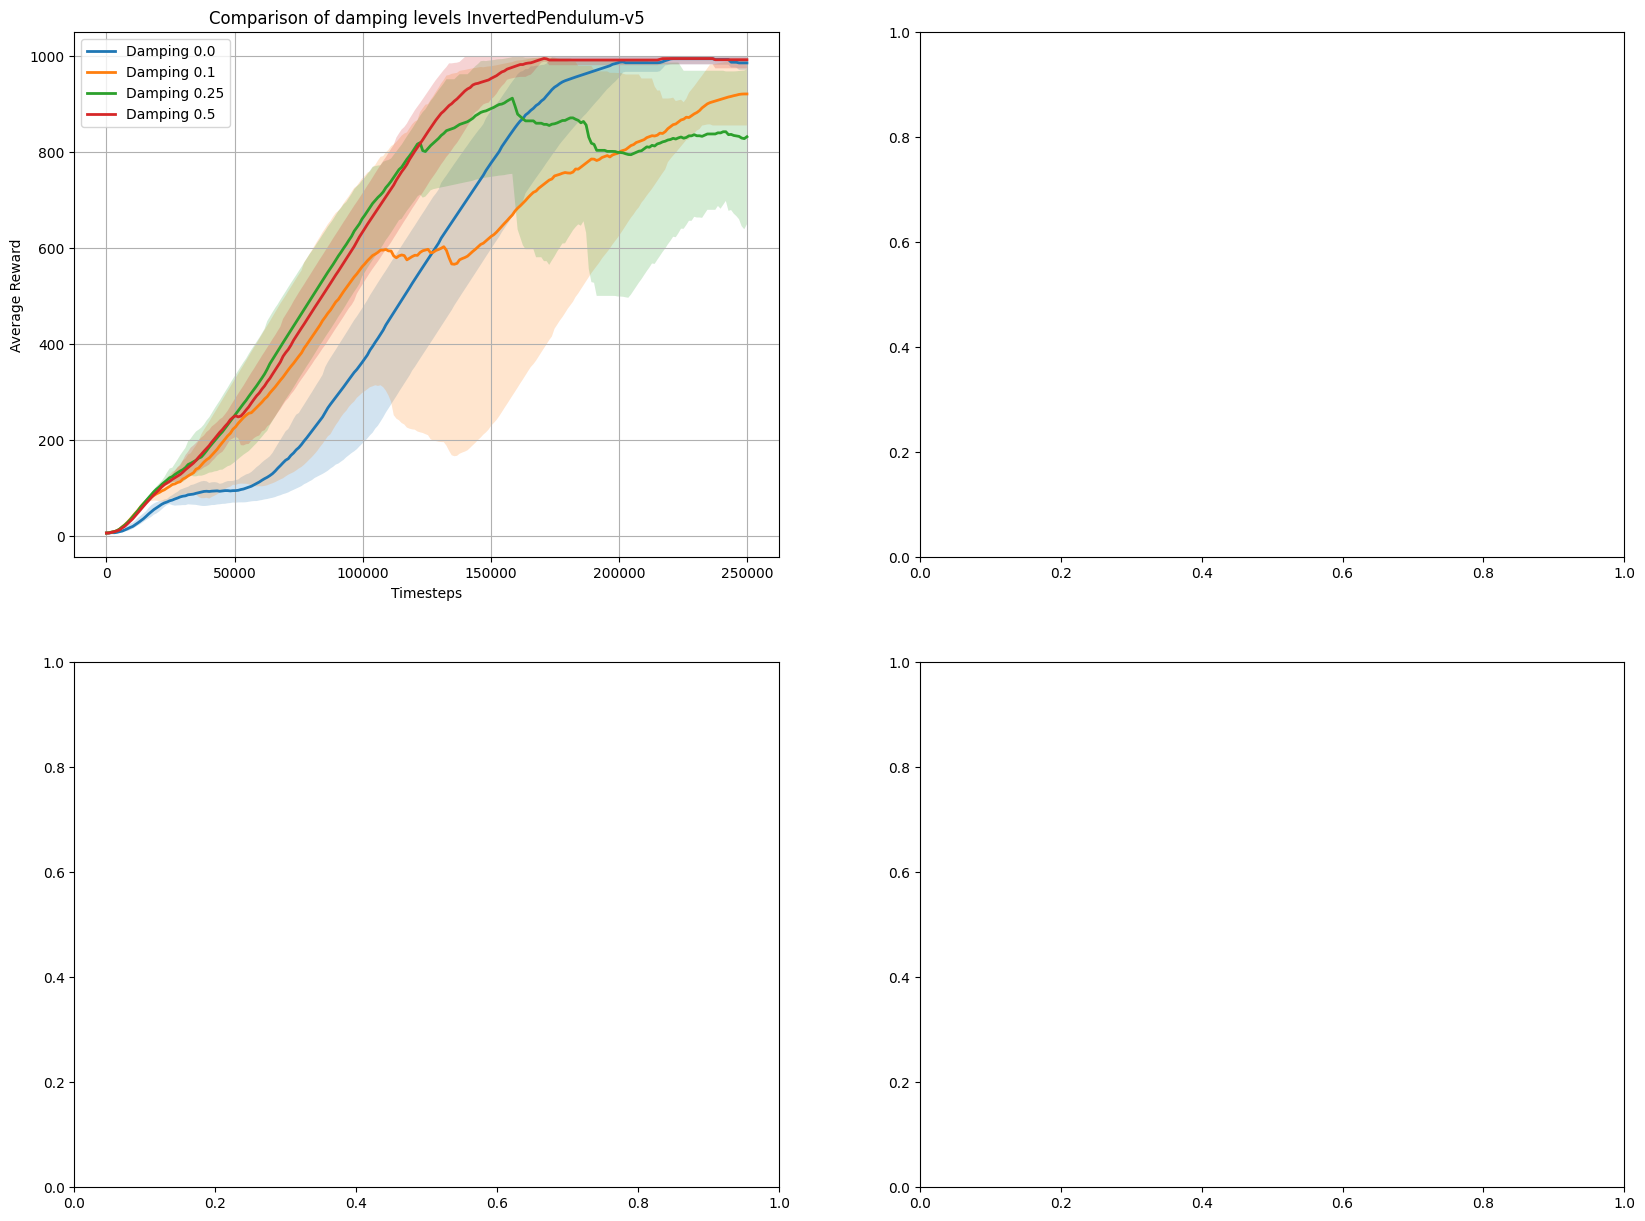

In [ ]:
import dill
import matplotlib.pyplot as plt
import numpy as np

env_ids = ["InvertedPendulum-v5", "Pendulum-v5", ]
dampings = ["0.0", "0.1", "0.25", "0.5"]
timesteps_final = 250000

fig, axes = plt.subplots(2, 2, figsize=(20, 15))
for damping, env_id, ax in zip(dampings, env_ids, axes.ravel()):
    with open(f'../results/trpo/objs/damping_{damping}_{env_id}.pl', 'rb') as file:
        results = dill.load(file)

    data = np.asarray(results['ep_rew_mean'])
    num_seeds, num_datapoints = data.shape
    means = np.mean(data, axis=0)
    timesteps = np.linspace(0, timesteps_final, num_datapoints)

    lower_bound = np.percentile(data, q=100-95, axis=0)
    upper_bound = np.percentile(data, q=95, axis=0)
    ax.plot(timesteps, means, label=f"Damping {damping}", linewidth=2)
    ax.fill_between(
        timesteps, 
        lower_bound, 
        upper_bound, 
        alpha=0.2, 
    )
    ax.set_title(f"Comparison of damping levels {env_id}")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Average Reward")
    ax.grid(True)
    ax.legend()
        